In [1]:
from weather_engine.database import engine
import pandas as pd
import xgboost as xgb
from weather_engine.llocv import load_fold, temporal_split_fold


FEATURES = ['rain', 'ws', 'td', 'rh', 'tdmax', 'tdmin', 'u_vec', 'v_vec']
TEST_STATION_ID = 16  # Afula — held out entirely, not used in training

station_neighbors: pd.DataFrame = pd.read_sql("SELECT * FROM station_neighbors", engine)
test_station_row = station_neighbors[station_neighbors["station_id"] == TEST_STATION_ID].iloc[0]

station_neighbors = station_neighbors[
    (station_neighbors["station_id"] != TEST_STATION_ID) &
    (station_neighbors["neighbor_1_id"] != TEST_STATION_ID) &
    (station_neighbors["neighbor_2_id"] != TEST_STATION_ID) &
    (station_neighbors["neighbor_3_id"] != TEST_STATION_ID)
].reset_index(drop=True)

In [2]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

all_X = []
all_y = []

all_data = pd.read_sql("SELECT * FROM clean_station_data", engine)
all_data['timestamp'] = pd.to_datetime(all_data['timestamp'])
all_data = all_data.set_index('timestamp').sort_index()
station_frames = {sid: grp.drop(columns='station_id') 
                  for sid, grp in all_data.groupby('station_id')}

X_test, y_test = load_fold(
    TEST_STATION_ID,
    int(test_station_row["neighbor_1_id"]),
    int(test_station_row["neighbor_2_id"]), 
    int(test_station_row["neighbor_3_id"]),
)

for _, row in station_neighbors.iterrows():
    X, y = load_fold(
        int(row["station_id"]),
        int(row["neighbor_1_id"]),
        int(row["neighbor_2_id"]), 
        int(row["neighbor_3_id"]),
        station_frames=station_frames
    )
    all_X.append(X)
    all_y.append(y)
print("All folds loaded.")


all_X = pd.concat(all_X).sort_index()
all_y = pd.concat(all_y).sort_index()

X_train, X_val, y_train, y_val = temporal_split_fold(all_X, all_y)

models = {}
errors = {}

for feature in FEATURES:
    print(f"[{FEATURES.index(feature) + 1}/{len(FEATURES)}] Training RFSI for '{feature}'...", end=' ')
    if feature == 'rain':
        model = xgb.XGBRegressor(n_jobs=-1, objective='reg:tweedie', tweedie_variance_power=1.5)
    else:
        model = xgb.XGBRegressor(n_jobs=-1, objective='reg:squarederror')
    model.fit(X_train, y_train[feature])
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val[feature], preds)
    rmse = root_mean_squared_error(y_val[feature], preds)
    errors[feature] = {'mae': mae, 'rmse': rmse}
    models[feature] = model
    print(f"MAE={mae:.4f}  RMSE={rmse:.4f}")



All folds loaded.
[1/8] Training RFSI for 'rain'... MAE=0.0335  RMSE=0.3489
[2/8] Training RFSI for 'ws'... MAE=1.0004  RMSE=1.3470
[3/8] Training RFSI for 'td'... MAE=1.4090  RMSE=1.8824
[4/8] Training RFSI for 'rh'... MAE=5.7260  RMSE=8.1614
[5/8] Training RFSI for 'tdmax'... MAE=1.4294  RMSE=1.9058
[6/8] Training RFSI for 'tdmin'... MAE=1.4210  RMSE=1.9019
[7/8] Training RFSI for 'u_vec'... MAE=1.1151  RMSE=1.5281
[8/8] Training RFSI for 'v_vec'... MAE=0.9532  RMSE=1.2956


Checking performance on rainy days only

In [3]:
rain_preds = models['rain'].predict(X_val)
rain_mask = y_val['rain'] >= 0.1

y_rain_true = y_val['rain'][rain_mask]
y_rain_pred = rain_preds[rain_mask]

mae_rain = mean_absolute_error(y_rain_true, y_rain_pred)
rmse_rain = root_mean_squared_error(y_rain_true, y_rain_pred)

print(f"Rain-only (>= 0.1mm) — n={rain_mask.sum()}")
print(f"MAE={mae_rain:.4f}  RMSE={rmse_rain:.4f}")


Rain-only (>= 0.1mm) — n=17571
MAE=0.8767  RMSE=1.9574


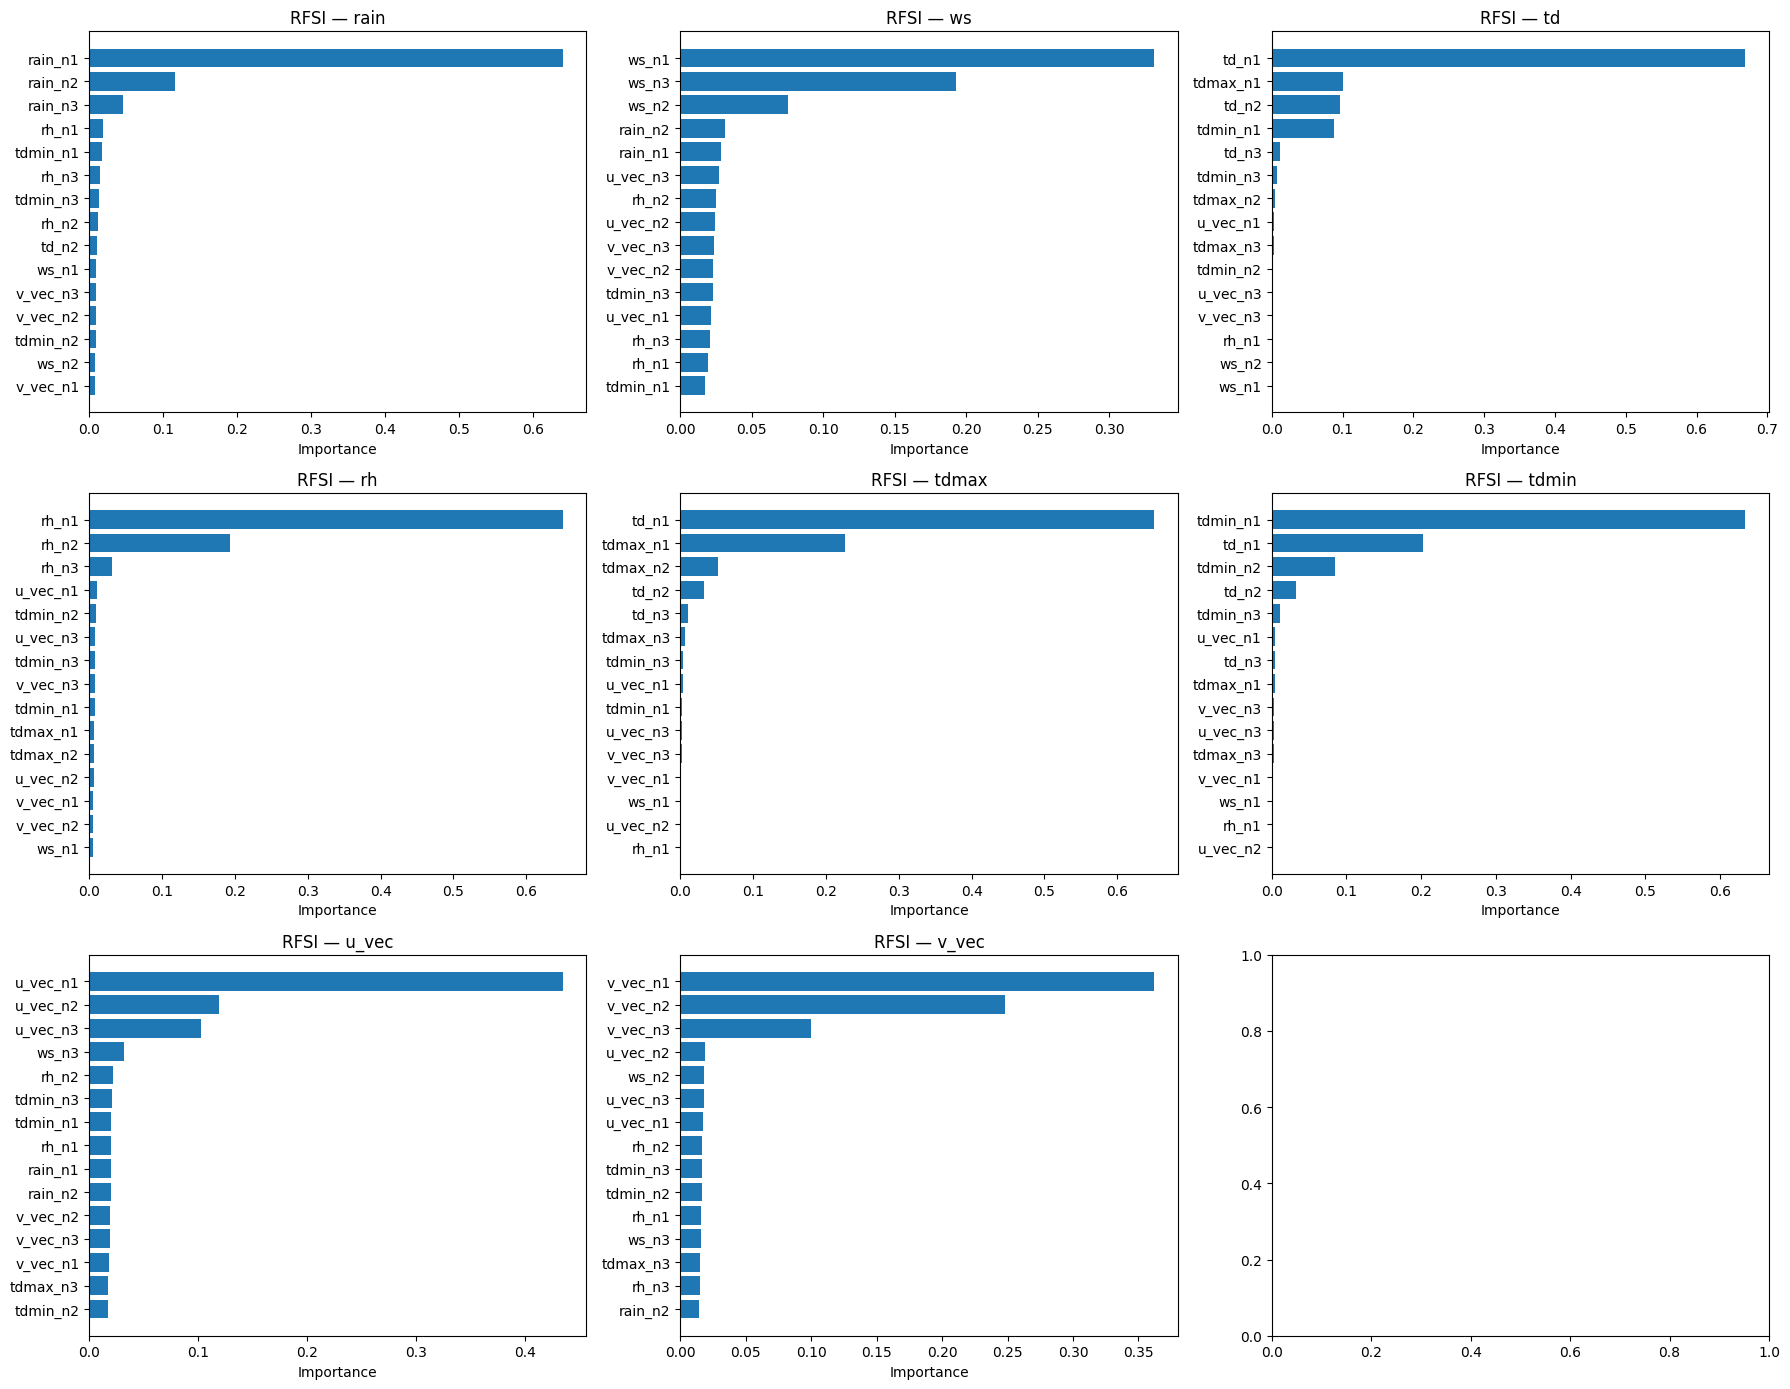

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (feature, model) in enumerate(models.items()):
    importances = model.feature_importances_
    feature_names = X_train.columns
    sorted_idx = importances.argsort()[::-1][:15]  # top 15

    axes[i].barh(feature_names[sorted_idx][::-1], importances[sorted_idx][::-1])
    axes[i].set_title(f'RFSI — {feature}')
    axes[i].set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [5]:
n1_dists = station_neighbors["neighbor_1_distance"].mean()
n2_dists = station_neighbors["neighbor_2_distance"].mean()
n3_dists = station_neighbors["neighbor_3_distance"].mean()

print(f"Mean of distance to neighbor 1: {n1_dists}\nMean of distance to neighbor 2: {n2_dists}\nMean of distance to neighbor 3: {n3_dists}")

Mean of distance to neighbor 1: 13.25037046883842
Mean of distance to neighbor 2: 19.61130247099956
Mean of distance to neighbor 3: 28.68110844356596


Those results explain why neighbor 3 in the feature importances is mostly the lowest in terms of impact, since the farther away a data source is the less relevant to our target weather.

rain: MAE=0.0460  RMSE=0.3301  RMSE(rain-only)=1.4917
ws: MAE=1.2244  RMSE=1.4205
td: MAE=1.4335  RMSE=1.8149
rh: MAE=4.5308  RMSE=6.1525
tdmax: MAE=1.3779  RMSE=1.7491
tdmin: MAE=1.4549  RMSE=1.8415
u_vec: MAE=1.0206  RMSE=1.2876
v_vec: MAE=0.8336  RMSE=1.0661


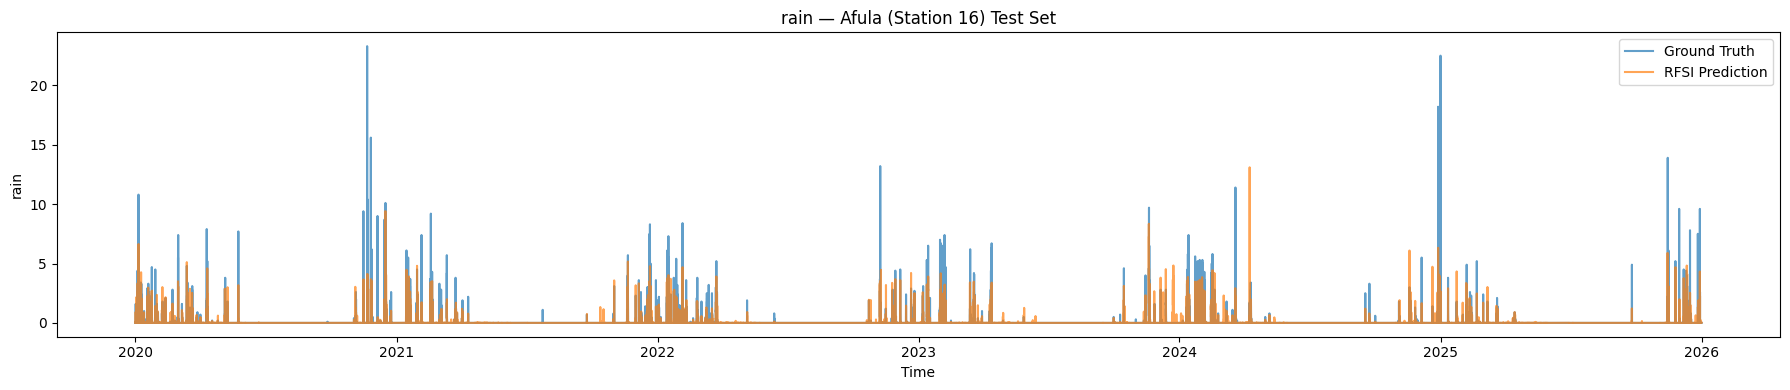

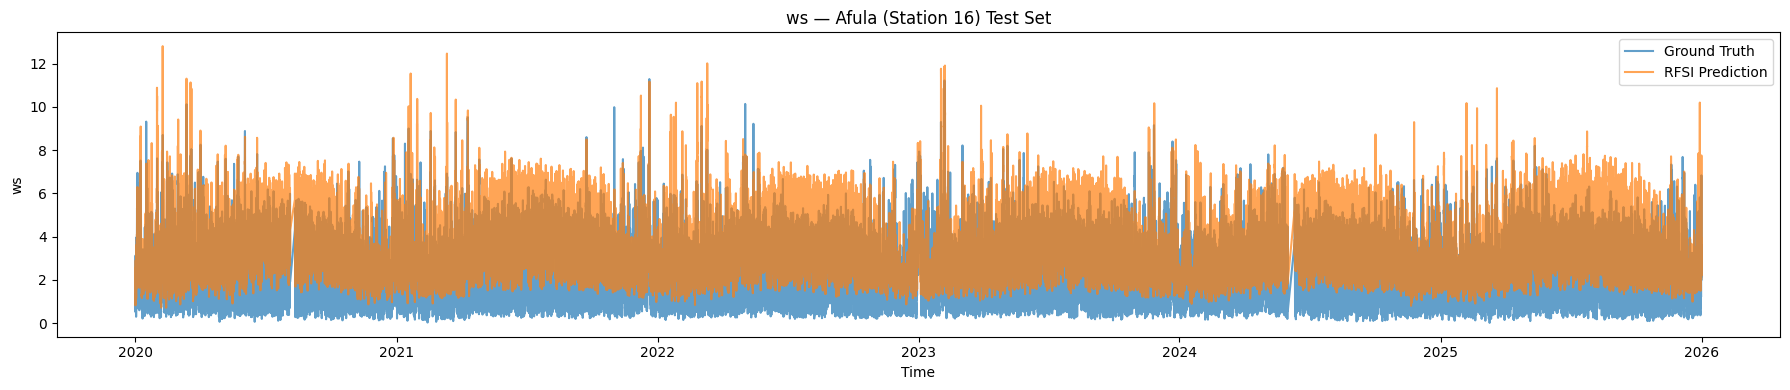

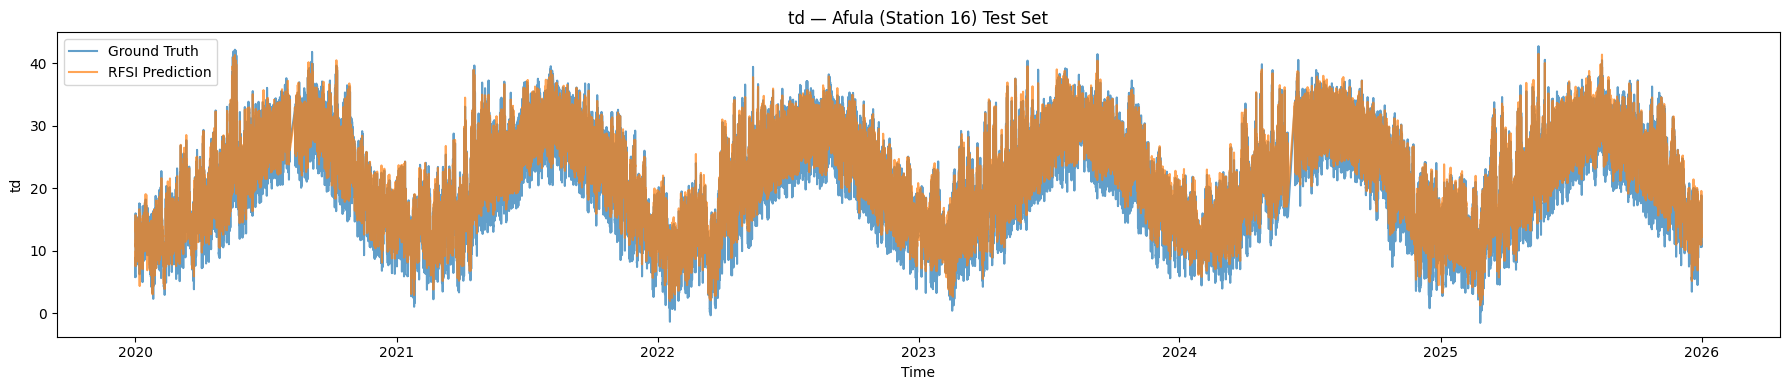

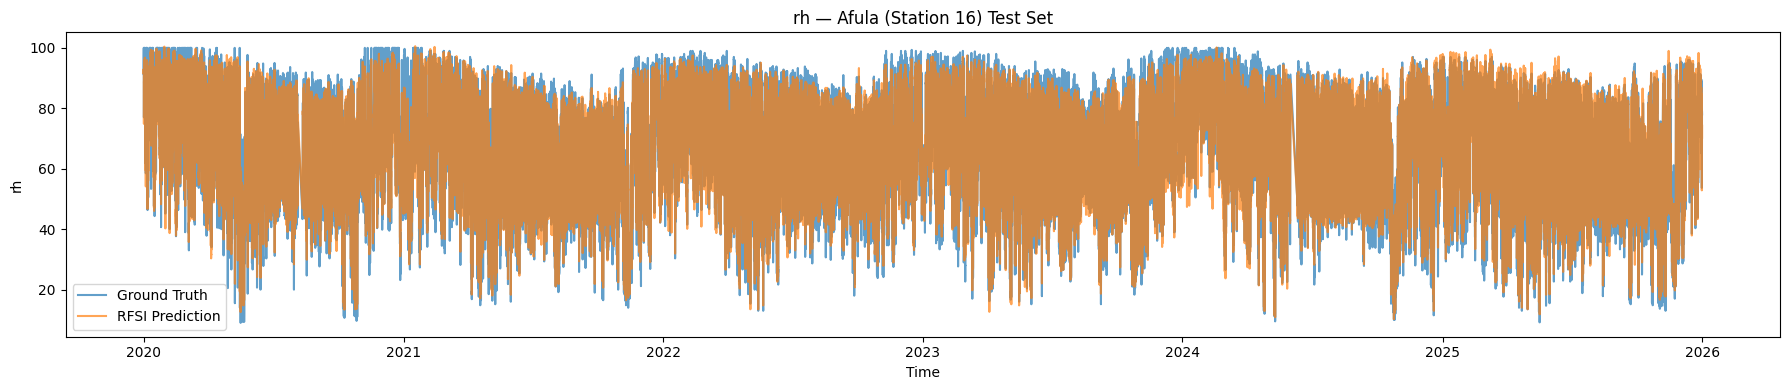

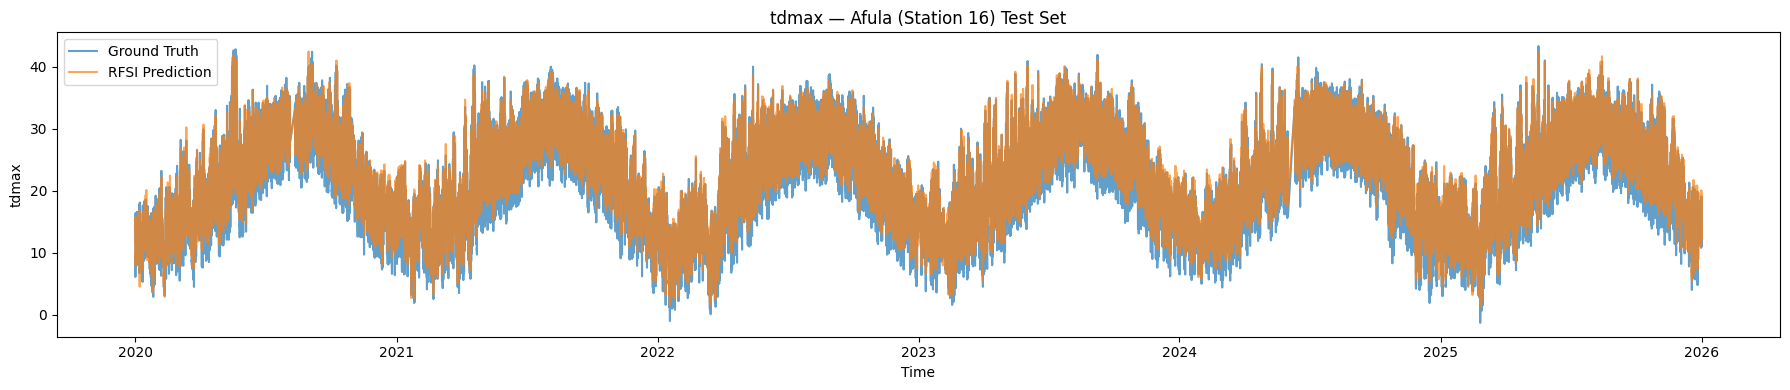

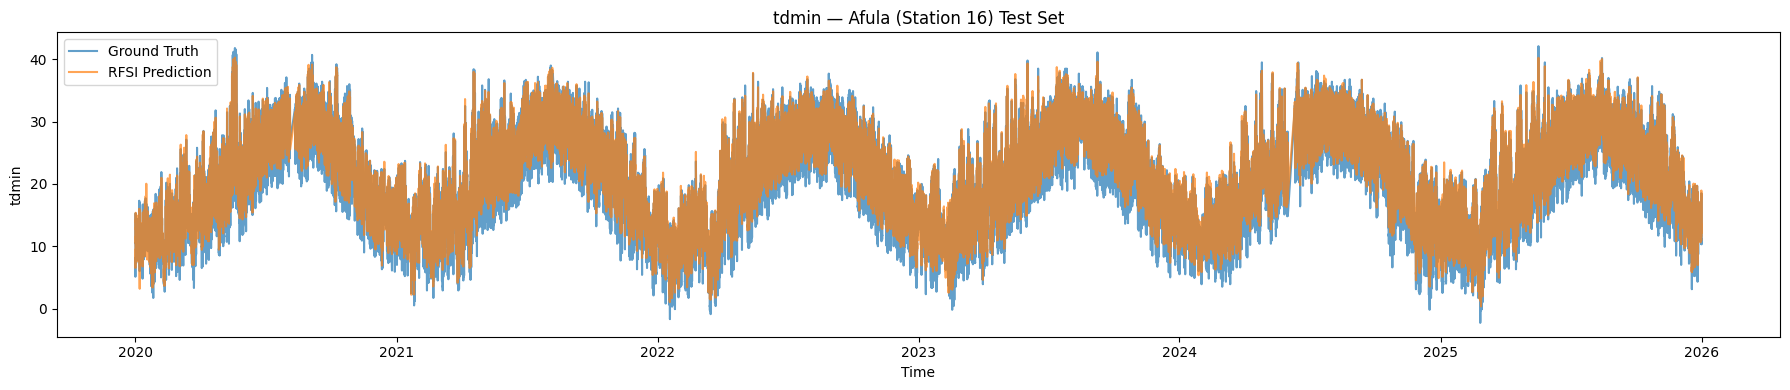

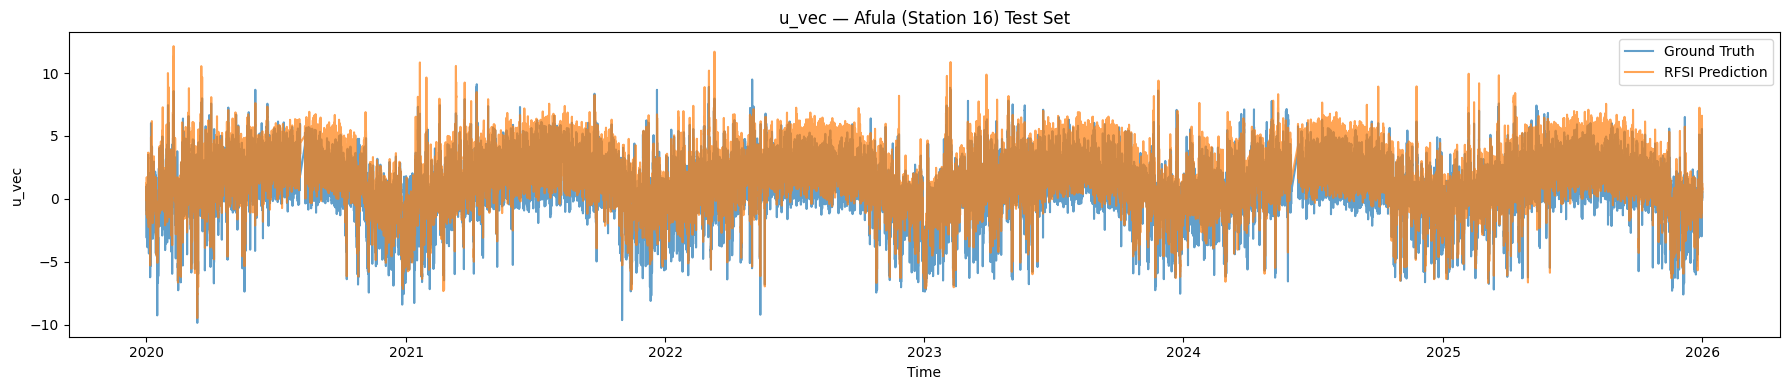

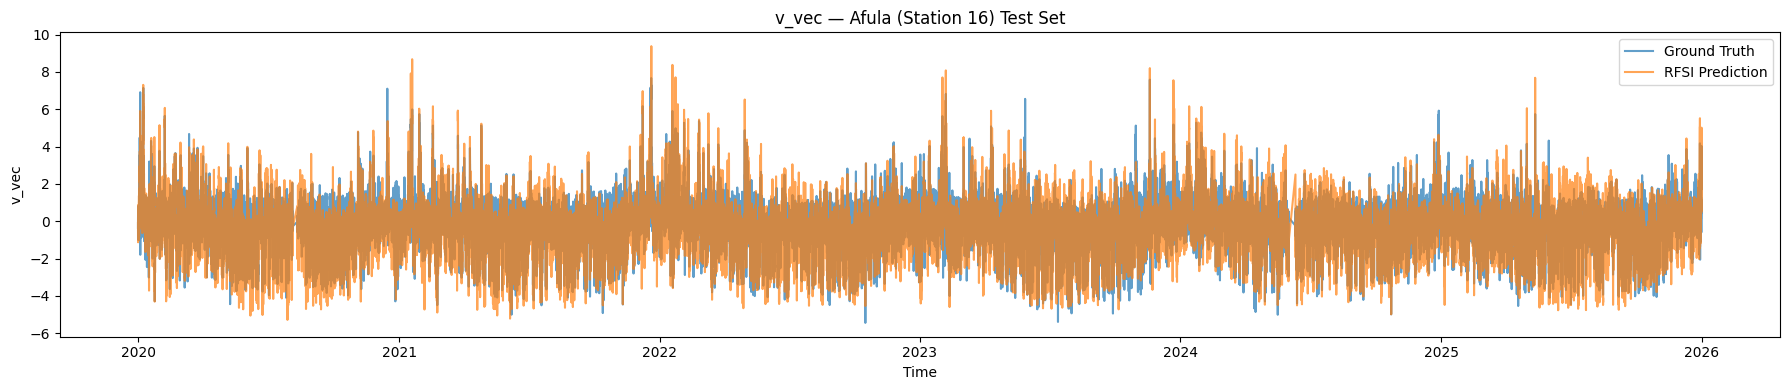

In [7]:
test_preds = {}

for feature, model in models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test[feature], preds)
    rmse = root_mean_squared_error(y_test[feature], preds)
    test_preds[feature] = preds
    
    if feature == 'rain':
        rain_mask = y_test[feature] >= 0.1
        rmse_rain = root_mean_squared_error(y_test[feature][rain_mask], preds[rain_mask])
        print(f"{feature}: MAE={mae:.4f}  RMSE={rmse:.4f}  RMSE(rain-only)={rmse_rain:.4f}")
    else:
        print(f"{feature}: MAE={mae:.4f}  RMSE={rmse:.4f}")


for feature, preds in test_preds.items():
    plt.figure(figsize=(18, 4))
    plt.plot(y_test.index, y_test[feature], label='Ground Truth', alpha=0.7)
    plt.plot(y_test.index, preds, label='RFSI Prediction', alpha=0.7)
    plt.title(f'{feature} — Afula (Station 16) Test Set')
    plt.xlabel('Time')
    plt.ylabel(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()
